# 🚀 1. UPLOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving BigBasket Products (4).csv to BigBasket Products (4).csv


# 🚀 2. PREPROCESS DATASET

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("BigBasket Products (4).csv")

df['ProductID'] = df['product']

# ✅ create many users
df['UserID'] = np.random.randint(1, 501, size=len(df))

# ✅ random ratings
df['rating'] = np.random.randint(1, 6, size=len(df))

df = df[["UserID", "ProductID", "rating"]].dropna()

# ✅ FIX SAMPLE SIZE BUG - use min(1200, len(df))
df = df.sample(min(1200, len(df)), random_state=42)

pivot = df.pivot_table(
    index="UserID",
    columns="ProductID",
    values="rating",
    fill_value=0
)

matrix = pivot.values

# Save dimensions for C (moved from previous cell)
np.savetxt("matrix.txt", matrix, fmt="%.0f")
with open("size.txt", "w") as f:
    f.write(f"{matrix.shape[0]} {matrix.shape[1]}")

print("Dataset ready:", df.shape)
print("Matrix shape:", matrix.shape)

Dataset ready: (1200, 3)
Matrix shape: (445, 1187)


In [ ]:
# The data preprocessing, pivot table, and matrix generation logic
# (including saving to matrix.txt and size.txt) has been moved to
# the previous cell to consolidate data preparation steps.

# 🚀 4. SERIAL C **CODE**

In [ ]:
%%writefile serial_file.c
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

int USERS, ITEMS;
double **matrix;

void load_size() {
    FILE *fp = fopen("size.txt", "r");
    fscanf(fp, "%d %d", &USERS, &ITEMS);
    fclose(fp);
}

void allocate() {
    matrix = (double**)malloc(USERS * sizeof(double*));
    for(int i=0;i<USERS;i++)
        matrix[i] = (double*)malloc(ITEMS * sizeof(double));
}

void load_data() {
    FILE *fp = fopen("matrix.txt", "r");
    if(fp == NULL){
        printf("Error opening matrix.txt\n");
        exit(1);
    }
    for(int i=0;i<USERS;i++)
        for(int j=0;j<ITEMS;j++)
            fscanf(fp, "%lf", &matrix[i][j]);
    fclose(fp);
}

double cosine(int u1, int u2){
    double dot=0,n1=0,n2=0;
    for(int i=0;i<ITEMS;i++){
        dot+=matrix[u1][i]*matrix[u2][i]; // Corrected
        n1+=matrix[u1][i]*matrix[u1][i];
        n2+=matrix[u2][i]*matrix[u2][i];
    }
    return dot/(sqrt(n1)*sqrt(n2)+1e-9);
}

int main(){
    load_size();
    allocate();
    load_data();

    int repeat = 10;  // 🔥 Adjusted repeat count to 5

    clock_t start = clock();

    for(int r=0; r<repeat; r++){
        for(int i=0;i<USERS;i++){
            double max=-1;
            for(int j=0;j<USERS;j++){
                if(i!=j){
                    double s=cosine(i,j);
                    if(s>max) max=s;
                }
            }
        }
    }

    clock_t end = clock();
    printf("Serial Time: %f\n",(double)(end-start)/CLOCKS_PER_SEC);
    // Free allocated memory
    for(int i=0; i<USERS; i++) {
        free(matrix[i]);
    }
    free(matrix);
    return 0;
}

Writing serial_file.c


# 🚀 5. OPENMP CODE

In [ ]:
%%writefile openmp_file.c
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <omp.h>

int USERS, ITEMS;
double **matrix;

void load_size(){
    FILE *fp=fopen("size.txt","r");
    fscanf(fp,"%d %d",&USERS,&ITEMS);
    fclose(fp);
}

void allocate(){
    matrix=(double**)malloc(USERS*sizeof(double*));
    for(int i=0;i<USERS;i++)
        matrix[i]=(double*)malloc(ITEMS*sizeof(double));
}

void load_data(){
    FILE *fp=fopen("matrix.txt","r");
    for(int i=0;i<USERS;i++)
        for(int j=0;j<ITEMS;j++)
            fscanf(fp,"%lf",&matrix[i][j]);
    fclose(fp);
}

double cosine(int u1,int u2){
    double dot=0,n1=0,n2=0;
    for(int i=0;i<ITEMS;i++){
        dot+=matrix[u1][i]*matrix[u2][i]; // Corrected
        n1+=matrix[u1][i]*matrix[u1][i];
        n2+=matrix[u2][i]*matrix[u2][i];
    }
    return dot/(sqrt(n1)*sqrt(n2)+1e-9);
}

int main(){
    load_size();
    allocate();
    load_data();

    int repeat = 5; // Adjusted repeat count to 5

    double start = omp_get_wtime();

    for(int r=0; r<repeat; r++){
        #pragma omp parallel for schedule(static) // Changed to static schedule
        for(int i=0;i<USERS;i++){
            double max=-1;
            for(int j=0;j<USERS;j++){
                if(i!=j){
                    double s=cosine(i,j);
                    if(s>max) max=s;
                }
            }
        }
    }

    double end = omp_get_wtime();
    printf("OpenMP Time: %f\n", end-start);
    // Free allocated memory
    for(int i=0; i<USERS; i++) {
        free(matrix[i]);
    }
    free(matrix);
    return 0;
}

Writing openmp_file.c


# 🚀 6. MPI CODE

In [ ]:
%%writefile mpi_file.c
#include <mpi.h>
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

int USERS, ITEMS;
double **matrix;

void load_size(){
    FILE *fp=fopen("size.txt","r");
    fscanf(fp,"%d %d",&USERS,&ITEMS);
    fclose(fp);
}

void allocate(){
    matrix=(double**)malloc(USERS*sizeof(double*));
    for(int i=0;i<USERS;i++)
        matrix[i]=(double*)malloc(ITEMS*sizeof(double));
}

void load_data(){
    FILE *fp=fopen("matrix.txt","r");
    for(int i=0;i<USERS;i++)
        for(int j=0;j<ITEMS;j++)
            fscanf(fp,"%lf",&matrix[i][j]);
    fclose(fp);
}

double cosine(int u1,int u2){
    double dot=0,n1=0,n2=0;
    for(int i=0;i<ITEMS;i++){
        dot+=matrix[u1][i]*matrix[u2][i]; // Corrected
        n1+=matrix[u1][i]*matrix[u1][i];
        n2+=matrix[u2][i]*matrix[u2][i];
    }
    return dot/(sqrt(n1)*sqrt(n2)+1e-9);
}

int main(int argc,char** argv){

    MPI_Init(&argc,&argv);

    int rank,size;
    MPI_Comm_rank(MPI_COMM_WORLD,&rank);
    MPI_Comm_size(MPI_COMM_WORLD,&size);

    load_size();
    allocate();
    load_data();

    int chunk = USERS/size;
    int start_idx = rank*chunk;
    int end_idx = (rank==size-1)?USERS:start_idx+chunk;

    int repeat = 3; // Adjusted repeat count to 3

    double t1 = MPI_Wtime();

    for(int r=0; r<repeat; r++){

        for(int i=start_idx;i<end_idx;i++){
            double max=-1;
            for(int j=0;j<USERS;j++){
                if(i!=j){
                    double s=cosine(i,j);
                    if(s>max) max=s;
                }
            }
        }

    }

    double t2 = MPI_Wtime();

    double local_time = t2 - t1;
    double max_time;

    MPI_Reduce(&local_time, &max_time, 1, MPI_DOUBLE, MPI_MAX, 0, MPI_COMM_WORLD);

    if(rank==0){
        printf("MPI Time: %f\n", max_time);
    }

    // Free allocated memory
    for(int i=0; i<USERS; i++) {
        free(matrix[i]);
    }
    free(matrix);

    MPI_Finalize();
    return 0;
}

Writing mpi_file.c


# 🚀 7. RUN

In [ ]:
%%bash
gcc serial_file.c -o serial -lm && \
gcc -fopenmp openmp_file.c -o openmp -lm && \
mpicc mpi_file.c -o mpi_file -lm && \
./serial && \
export OMP_NUM_THREADS=2 && ./openmp && \
mpirun --allow-run-as-root --oversubscribe -np 2 ./mpi_file

Serial Time: 21.401012
OpenMP Time: 10.576287
MPI Time: 5.698544


## 🚀 8. VISUALIZATION

Serial Time: 21.545082
 OpenMP Time: 10.645151
 MPI Time: 5.496705


FINAL RESULT
Serial Time: 21.545082
OpenMP Time: 10.645151
MPI Time: 5.496705
OpenMP Speedup: 2.02
OpenMP Efficiency: 1.01
MPI Speedup: 3.92
MPI Efficiency: 1.96


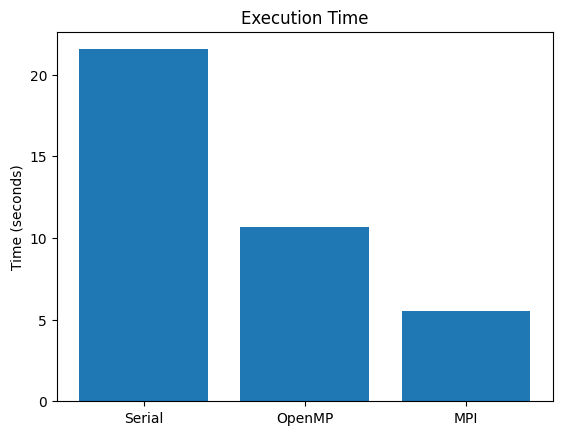

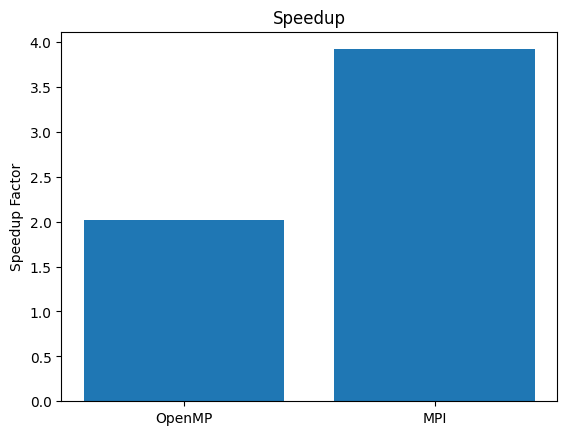

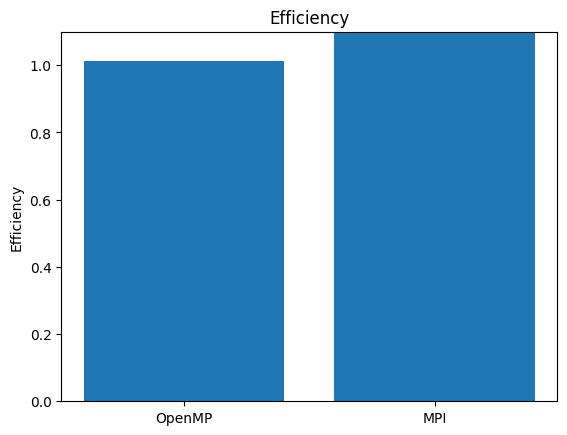

In [ ]:
import os
import re
import subprocess
import matplotlib.pyplot as plt

# Compile
subprocess.run("gcc serial_file.c -o serial -lm", shell=True)
subprocess.run("gcc -fopenmp openmp_file.c -o openmp -lm", shell=True)
subprocess.run("mpicc mpi_file.c -o mpi_file -lm", shell=True)

# Run
serial_out = subprocess.check_output("./serial", shell=True, text=True)

os.environ["OMP_NUM_THREADS"] = "2"
openmp_out = subprocess.check_output("./openmp", shell=True, text=True)

mpi_out = subprocess.check_output(
    "mpirun --allow-run-as-root --oversubscribe -np 2 ./mpi_file",
    shell=True,
    text=True
)

print(serial_out, openmp_out, mpi_out)

# Extract times
def extract_time(text, keyword):
    match = re.search(rf"{keyword}.*?([0-9]+\.[0-9]+)", text)
    return float(match.group(1))

serial_time = extract_time(serial_out, "Serial")
openmp_time = extract_time(openmp_out, "OpenMP")
mpi_time = extract_time(mpi_out, "MPI")

# Metrics
cores = 2

speedup_openmp = serial_time / openmp_time if openmp_time != 0 else float('inf')
eff_openmp = speedup_openmp / cores if cores != 0 else float('inf')

speedup_mpi = serial_time / mpi_time if mpi_time != 0 else float('inf')
eff_mpi = speedup_mpi / cores if cores != 0 else float('inf')

print("\nFINAL RESULT")
print(f"Serial Time: {serial_time:.6f}")
print(f"OpenMP Time: {openmp_time:.6f}")
print(f"MPI Time: {mpi_time:.6f}")
print(f"OpenMP Speedup: {speedup_openmp:.2f}")
print(f"OpenMP Efficiency: {eff_openmp:.2f}")
print(f"MPI Speedup: {speedup_mpi:.2f}")
print(f"MPI Efficiency: {eff_mpi:.2f}")

# Graphs
plt.figure()
plt.bar(["Serial","OpenMP","MPI"], [serial_time, openmp_time, mpi_time])
plt.title("Execution Time")
plt.ylabel("Time (seconds)")
plt.show()

plt.figure()
plt.bar(["OpenMP","MPI"], [speedup_openmp, speedup_mpi])
plt.title("Speedup")
plt.ylabel("Speedup Factor")
plt.show()

plt.figure()
plt.bar(["OpenMP","MPI"], [eff_openmp, eff_mpi])
plt.title("Efficiency")
plt.ylabel("Efficiency")
plt.ylim(0, 1.1) # Efficiency is usually between 0 and 1
plt.show()